# Voice under Stress - Analysis

import of all functions needed

In [6]:
import os
import sys
import pandas as pd
import datetime as dt
import imageio
import numpy as np
import subprocess
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import scipy 
import math
import shap

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, precision_recall_curve, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, LeaveOneOut, StratifiedKFold, StratifiedShuffleSplit, train_test_split
from sklearn import metrics, svm, linear_model
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler, StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

from scipy import stats
from scipy.stats import skew, kurtosis
from statsmodels.stats.descriptivestats import sign_test

# fix random seed for reproducibility
np.random.seed(42)

In [7]:
pd.set_option('display.max_columns', None)

In [8]:
homepath=os.getcwd()
scripts_path=os.path.join(homepath, 'scripts')
sys.path.append(scripts_path)
import myml
import mystress
import myvoice

In [ ]:
# Check version of Python==64
!python -c "import sys; print(sys.maxsize > 2**32)"

# random seed for reproducability
np.random.seed(42)

# show all columns of dataframes
pd.set_option('display.max_columns', None)

# set current dir to highest hierachy to add data path
os.chdir('/')
data_folder='/data'
sys.path.append(data_folder)
os.chdir(homepath)

True


# Main Code

### Step 1: load data and calculate variables

In [ ]:
filename_librosa='./processed_nemo_data/features.csv'
filename_behavior=data_folder + '/raw/TSST_behavior.csv'
filename_praat='./processed_nemo_data/new_praat_results'
filename_opensmile='./processed_nemo_data/opensmile_features.csv'
filename_output='./processed_nemo_data/df_vpn'

df, librosa_featurenames, praat_featurenames, opensimle_feature=mystress.load_df(filename_opensmile, filename_praat, 
                                                 filename_librosa, filename_behavior, filename_output)
df=mystress.calc_var(df)

In [11]:
audio=praat_featurenames +librosa_featurenames[0:40]+list(opensimle_feature)
audio.append('Sex')

In [12]:
small_audio=['meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localShimmer', 'energy', 'length', 'Sex']

# Classification

In [13]:
X, y, vpn = myml.split_and_shuffle(df,  audio, 'Cond')

Shape of X:
(50, 144)
Shape of y:
(50,)


# Simple Logistic Regression

### without any parameter tuning.

>acc=0.800
>acc=0.400
>acc=0.800
>acc=0.800
>acc=1.000
>acc=0.800
>acc=0.600
>acc=1.000
>acc=0.600
>acc=1.000

y_true (echte Labels):
  Klasse 0 → 25 Samples
  Klasse 1 → 25 Samples

y_pred (Vorhersagen):
  Klasse 0 → 26 Samples
  Klasse 1 → 24 Samples
Accuracy: 0.780 (± 0.189)
F1-Score: 0.721 (± 0.309)


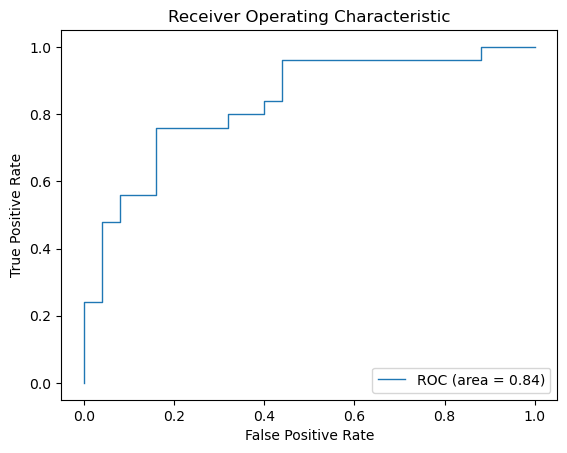

Crossvalidierte Ergebnisse on test data
              precision    recall  f1-score   support

           0       0.77      0.80      0.78        25
           1       0.79      0.76      0.78        25

    accuracy                           0.78        50
   macro avg       0.78      0.78      0.78        50
weighted avg       0.78      0.78      0.78        50

Crossvalidierte Ergebnisse on training data
              precision    recall  f1-score   support

           0       0.68      0.68      0.68        25
           1       0.68      0.68      0.68        25

    accuracy                           0.68        50
   macro avg       0.68      0.68      0.68        50
weighted avg       0.68      0.68      0.68        50



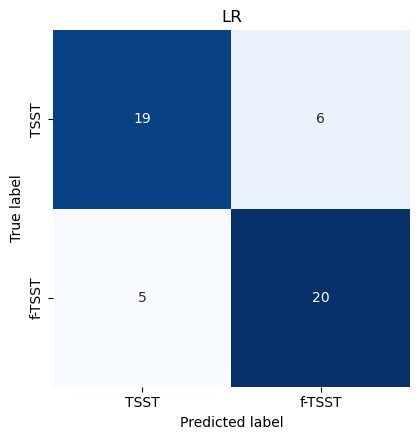

In [14]:
m = LogisticRegression(
    C=0.5,
    solver="saga",
    l1_ratio=0,      # L2
    max_iter=10000
)

res_lr = myml.classification_10foldcv(X, y, m, 'LR', 'yes')
res_lr.columns = ["y_true", "y_score"] 


### with hyperparameter tuning (nested cv)

Here we are using a 10-fold Stratified Cross-Validation with nested 3-fold CV for hyperparameter tuning.
In each outer fold, the best model is selected using GridSearchCV on the training data
and then evaluated on the held-out test fold. Performance is compared to a majority
class baseline and repeated for all folds.



>acc=0.800
>acc=0.400
>acc=0.800
>acc=0.400
>acc=1.000
>acc=1.000
>acc=0.600
>acc=1.000
>acc=0.800
>acc=1.000
                             Variable  Importance
137              VoicedSegmentsPerSec    0.946509
82              mfcc3_sma3_stddevNorm    0.809828
136               loudnessPeaksPerSec    0.681608
88   shimmerLocaldB_sma3nz_stddevNorm    0.613136
25                        spectrum_10    0.572342
Accuracy: 0.780 (± 0.227)
F1-Score: 0.743 (± 0.314)


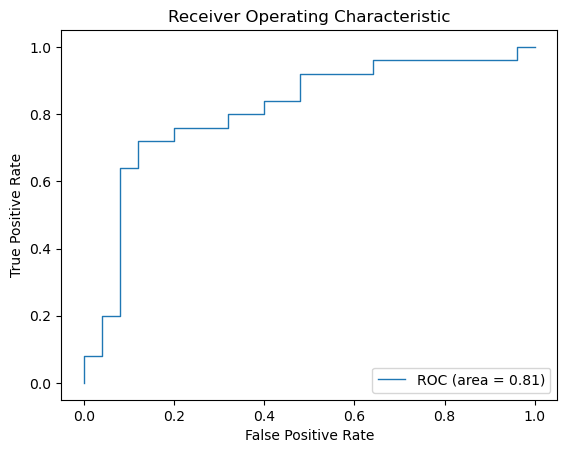


Crossvalidierte Ergebnisse on test data
              precision    recall  f1-score   support

           0       0.77      0.80      0.78        25
           1       0.79      0.76      0.78        25

    accuracy                           0.78        50
   macro avg       0.78      0.78      0.78        50
weighted avg       0.78      0.78      0.78        50

Saved CSV (fold scores): LR-nested_kfold_fold_scores.csv


In [15]:
m = LogisticRegression(
    solver="saga",
    max_iter=10000,
    class_weight="balanced"
)
space = {
    "C": [10, 1, 0.5, 0.1, 0.01],
    "l1_ratio": [0, 1]   # L2 vs L1
}

feat_imp, importance_df, res_lr_nested = myml.classification_10foldcv_nested_feature_importance_LR(X, y, m, space, 'yes', audio=audio, df=df)
res_lr_nested.columns = ["y_true", "y_score"] 

### with hyperparameter tuning (nested cv) and pca

Here we are using a 10-fold Stratified Cross-Validation with nested 3-fold CV for hyperparameter tuning.
A pipeline consisting of StandardScaler, PCA, and the classifier is used.
In each outer fold, the training data is used in a GridSearchCV with 3-fold CV
to select the best hyperparameters. PCA and scaling are fitted only on the
training data within each fold to avoid data leakage. The best pipeline is
then evaluated on the held-out test fold. This process is repeated for all folds.

>acc=0.800, est=0.844, cfg={'model__C': 1, 'model__l1_ratio': 0, 'pca__n_components': 30}
>acc=0.400, est=0.933, cfg={'model__C': 10, 'model__l1_ratio': 0, 'pca__n_components': 25}
>acc=0.800, est=0.844, cfg={'model__C': 10, 'model__l1_ratio': 0, 'pca__n_components': 30}
>acc=0.400, est=0.778, cfg={'model__C': 0.1, 'model__l1_ratio': 1, 'pca__n_components': 5}
>acc=1.000, est=0.822, cfg={'model__C': 0.5, 'model__l1_ratio': 1, 'pca__n_components': 15}
>acc=0.600, est=0.800, cfg={'model__C': 10, 'model__l1_ratio': 0, 'pca__n_components': 15}
>acc=0.600, est=0.800, cfg={'model__C': 1, 'model__l1_ratio': 0, 'pca__n_components': 30}
>acc=0.800, est=0.800, cfg={'model__C': 10, 'model__l1_ratio': 1, 'pca__n_components': 25}
>acc=0.800, est=0.822, cfg={'model__C': 10, 'model__l1_ratio': 1, 'pca__n_components': 20}
>acc=1.000, est=0.822, cfg={'model__C': 1, 'model__l1_ratio': 1, 'pca__n_components': 25}

y_true (echte Labels):
  Klasse 0 → 25 Samples
  Klasse 1 → 25 Samples

y_pred (Vorhersagen

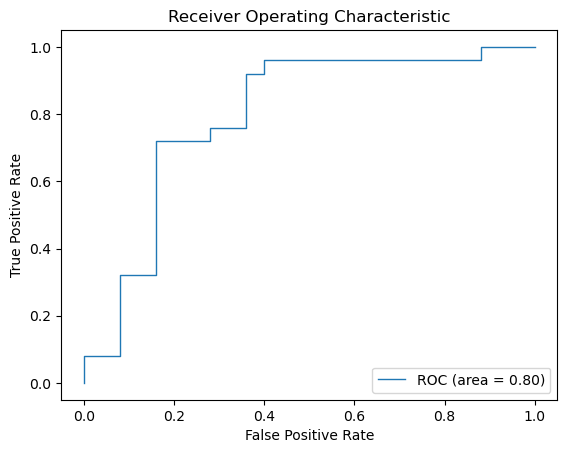

Crossvalidierte Ergebnisse on test data
              precision    recall  f1-score   support

           0       0.72      0.72      0.72        25
           1       0.72      0.72      0.72        25

    accuracy                           0.72        50
   macro avg       0.72      0.72      0.72        50
weighted avg       0.72      0.72      0.72        50



In [16]:
m = LogisticRegression(
    solver="saga",
    max_iter=10000,
    class_weight="balanced"
)
space = {
    "model__C": [10, 1, 0.5, 0.1, 0.01],
    "model__l1_ratio": [0, 1],   # L2 vs L1
    "pca__n_components": [5, 10, 15, 20, 25, 30]
}

res_lr_nested_pca = myml.classification_10foldcv_nested_with_pca(X, y, m, space, 'yes')
res_lr_nested_pca.columns = ["y_true", "y_score"] 

# Random Forest Classifier

#### Without Hyperparameter-Tuning

>acc=0.800
>acc=0.400
>acc=1.000
>acc=0.800
>acc=1.000
>acc=1.000
>acc=0.600
>acc=0.800
>acc=0.800
>acc=0.800

y_true (echte Labels):
  Klasse 0 → 25 Samples
  Klasse 1 → 25 Samples

y_pred (Vorhersagen):
  Klasse 0 → 27 Samples
  Klasse 1 → 23 Samples
Accuracy: 0.800 (± 0.179)
F1-Score: 0.777 (± 0.196)


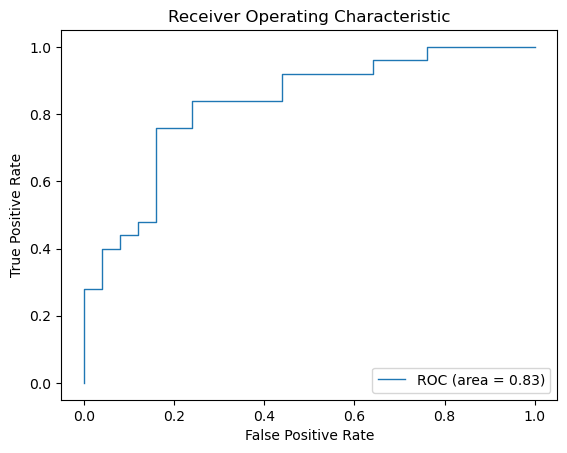

Crossvalidierte Ergebnisse on test data
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        25
           1       0.83      0.76      0.79        25

    accuracy                           0.80        50
   macro avg       0.80      0.80      0.80        50
weighted avg       0.80      0.80      0.80        50

Crossvalidierte Ergebnisse on training data
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        25
           1       0.80      0.80      0.80        25

    accuracy                           0.80        50
   macro avg       0.80      0.80      0.80        50
weighted avg       0.80      0.80      0.80        50



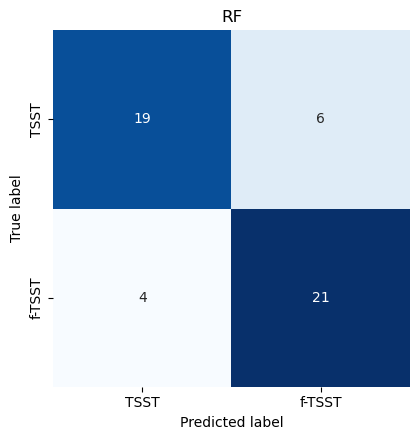

In [17]:
model = RandomForestClassifier(n_estimators=1000, max_depth=2, max_features='sqrt', min_samples_leaf=3)

res_rf = myml.classification_10foldcv(X, y, model, 'RF')
res_rf.columns = ["y_true", "y_score"] 

### with hyperparameter tuning (nested cv)

Here we are using a 10-fold Stratified Cross-Validation with nested 3-fold CV for hyperparameter tuning.
In each outer fold, the best model is selected using GridSearchCV on the training data
and then evaluated on the held-out test fold. Performance is compared to a majority
class baseline and repeated for all folds.

>acc=0.800
>acc=0.400
>acc=1.000
>acc=0.800
>acc=1.000
>acc=1.000
>acc=0.600
>acc=0.800
>acc=0.800
>acc=0.800

y_true (echte Labels):
  Klasse 0 → 25 Samples
  Klasse 1 → 25 Samples

y_pred (Vorhersagen):
  Klasse 0 → 27 Samples
  Klasse 1 → 23 Samples

y_pred_base (Baseline):
  Klasse 0 → 25 Samples
  Klasse 1 → 25 Samples
Accuracy: 0.800 (± 0.179)
F1-Score: 0.777 (± 0.196)


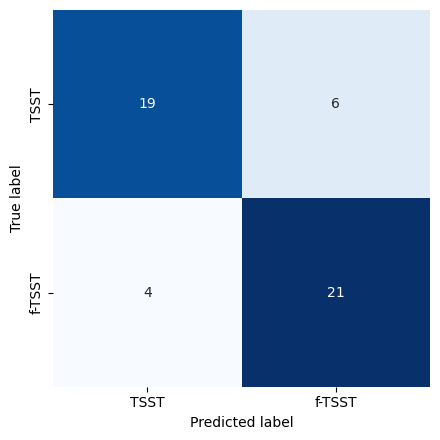

McNemar (Model vs Baseline)
statistic=13.884615384615385, p-value=0.0001943831223353872


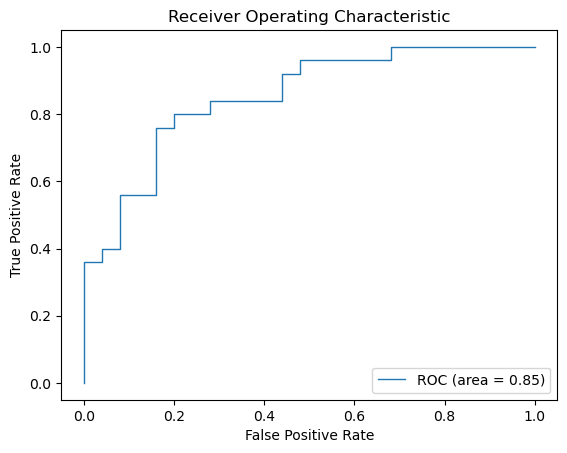

Crossvalidierte Ergebnisse on test data
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        25
           1       0.83      0.76      0.79        25

    accuracy                           0.80        50
   macro avg       0.80      0.80      0.80        50
weighted avg       0.80      0.80      0.80        50

Crossvalidierte Ergebnisse on training data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        25
           1       1.00      1.00      1.00        25

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

Saved CSV (fold scores): rf - nested_classification_kfold_fold_scores.csv


In [ ]:
model = RandomForestClassifier(random_state=1, n_estimators=1000)

space = dict()
space['max_depth'] = [1, 2, 4, 8]
space ['min_samples_leaf']=[1, 2, 4]

res_rf_nested = myml.classification_10foldcv_nested(X, y, model, 'rf - nested', space, 'no')
res_rf_nested.columns = ["y_true", "y_score"] 

>acc=0.800, est=0.822, cfg={'model__max_depth': 1, 'model__min_samples_leaf': 1, 'pca__n_components': 10}
>acc=0.400, est=0.756, cfg={'model__max_depth': 2, 'model__min_samples_leaf': 1, 'pca__n_components': 20}
>acc=1.000, est=0.778, cfg={'model__max_depth': 4, 'model__min_samples_leaf': 1, 'pca__n_components': 20}
>acc=0.800, est=0.756, cfg={'model__max_depth': 4, 'model__min_samples_leaf': 1, 'pca__n_components': 20}
>acc=0.600, est=0.756, cfg={'model__max_depth': 8, 'model__min_samples_leaf': 1, 'pca__n_components': 5}
>acc=0.800, est=0.733, cfg={'model__max_depth': 2, 'model__min_samples_leaf': 1, 'pca__n_components': 30}
>acc=0.400, est=0.800, cfg={'model__max_depth': 1, 'model__min_samples_leaf': 1, 'pca__n_components': 30}
>acc=0.800, est=0.844, cfg={'model__max_depth': 1, 'model__min_samples_leaf': 4, 'pca__n_components': 30}
>acc=1.000, est=0.733, cfg={'model__max_depth': 4, 'model__min_samples_leaf': 1, 'pca__n_components': 25}
>acc=1.000, est=0.667, cfg={'model__max_depth':

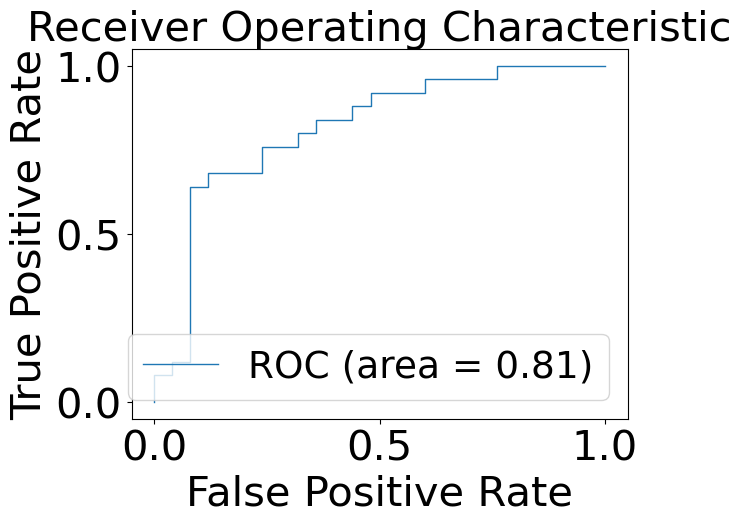

Crossvalidierte Ergebnisse on test data
              precision    recall  f1-score   support

           0       0.72      0.84      0.78        25
           1       0.81      0.68      0.74        25

    accuracy                           0.76        50
   macro avg       0.77      0.76      0.76        50
weighted avg       0.77      0.76      0.76        50



In [32]:
model = RandomForestClassifier(random_state=1, n_estimators=1000)

space = {
    "pca__n_components": [5, 10, 15, 20, 25, 30],
    "model__max_depth": [1, 2, 4, 8],
    "model__min_samples_leaf": [1, 2, 4],
}

res_rf_nested_pca = myml.classification_10foldcv_nested_with_pca(X, y, model, space, 'yes')
res_rf_nested_pca.columns = ["y_true", "y_score"] 

## Support Vector Machine

### without any hyperparameter tuning

>acc=0.800
>acc=0.400
>acc=0.800
>acc=0.800
>acc=1.000
>acc=0.800
>acc=0.600
>acc=1.000
>acc=0.600
>acc=1.000

y_true (echte Labels):
  Klasse 0 → 25 Samples
  Klasse 1 → 25 Samples

y_pred (Vorhersagen):
  Klasse 0 → 26 Samples
  Klasse 1 → 24 Samples
Accuracy: 0.780 (± 0.189)
F1-Score: 0.721 (± 0.309)


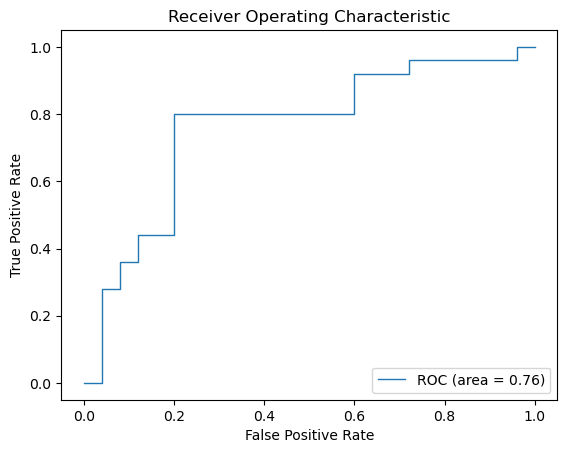

Crossvalidierte Ergebnisse on test data
              precision    recall  f1-score   support

           0       0.77      0.80      0.78        25
           1       0.79      0.76      0.78        25

    accuracy                           0.78        50
   macro avg       0.78      0.78      0.78        50
weighted avg       0.78      0.78      0.78        50

Crossvalidierte Ergebnisse on training data
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        25
           1       0.80      0.80      0.80        25

    accuracy                           0.80        50
   macro avg       0.80      0.80      0.80        50
weighted avg       0.80      0.80      0.80        50



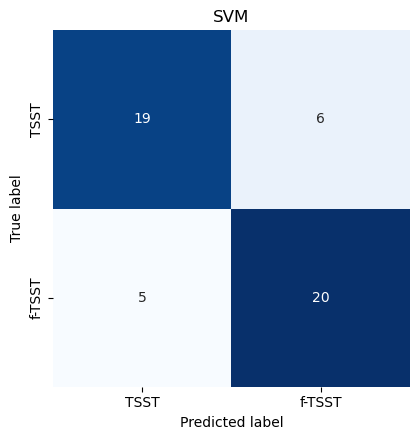

In [19]:
model = SVC(kernel='linear', degree=3, gamma='scale', probability=True, class_weight='balanced')

res_svm = myml.classification_10foldcv(X, y, model, 'SVM', 'yes')
res_svm.columns = ["y_true", "y_score"] 

### with hyperparameter tuning (nested cv)

Here we are using a 10-fold Stratified Cross-Validation with nested 3-fold CV for hyperparameter tuning.
In each outer fold, the best model is selected using GridSearchCV on the training data
and then evaluated on the held-out test fold. Performance is compared to a majority
class baseline and repeated for all folds.

>acc=0.800
>acc=0.400
>acc=0.800
>acc=0.800
>acc=1.000
>acc=0.600
>acc=0.600
>acc=1.000
>acc=0.800
>acc=0.600

y_true (echte Labels):
  Klasse 0 → 25 Samples
  Klasse 1 → 25 Samples

y_pred (Vorhersagen):
  Klasse 0 → 26 Samples
  Klasse 1 → 24 Samples

y_pred_base (Baseline):
  Klasse 0 → 25 Samples
  Klasse 1 → 25 Samples
Accuracy: 0.740 (± 0.180)
F1-Score: 0.671 (± 0.300)


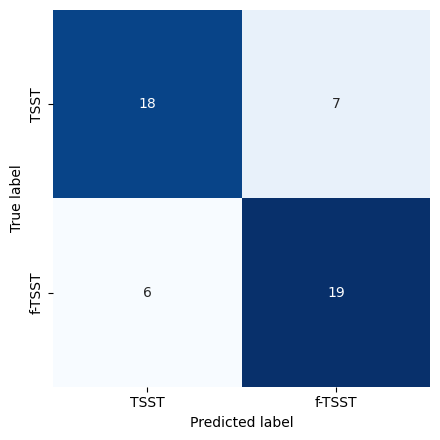

McNemar (Model vs Baseline)
statistic=8.258064516129032, p-value=0.004057136032371287


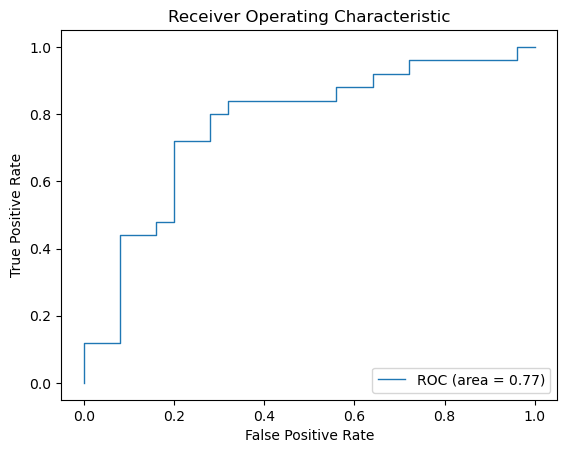

Crossvalidierte Ergebnisse on test data
              precision    recall  f1-score   support

           0       0.73      0.76      0.75        25
           1       0.75      0.72      0.73        25

    accuracy                           0.74        50
   macro avg       0.74      0.74      0.74        50
weighted avg       0.74      0.74      0.74        50

Crossvalidierte Ergebnisse on training data
              precision    recall  f1-score   support

           0       0.59      0.76      0.67        25
           1       0.67      0.48      0.56        25

    accuracy                           0.62        50
   macro avg       0.63      0.62      0.61        50
weighted avg       0.63      0.62      0.61        50

Saved CSV (fold scores): svm - nested_classification_kfold_fold_scores.csv


In [20]:
model = SVC(kernel='rbf', degree=3, gamma='scale', probability=True, class_weight='balanced')

space = dict()
space['C'] = [10, 1.0, 0.1, 0.01]
space['kernel'] = ['linear', 'rbf']
gamma = ['scale',0.001, 0.01, 0.1, 1, 10]
 
res_svm_nested = myml.classification_10foldcv_nested(X, y, model, 'svm - nested', space, 'yes')
res_svm_nested.columns = ["y_true", "y_score"] 


### with hyperparameter tuning (nested cv) and pca

Here we are using a 10-fold Stratified Cross-Validation with nested 3-fold CV for hyperparameter tuning.
A pipeline consisting of StandardScaler, PCA, and the classifier is used.
In each outer fold, the training data is used in a GridSearchCV with 3-fold CV
to select the best hyperparameters. PCA and scaling are fitted only on the
training data within each fold to avoid data leakage. The best pipeline is
then evaluated on the held-out test fold. This process is repeated for all folds.

>acc=0.800, est=0.844, cfg={'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear', 'pca__n_components': 20}
>acc=0.400, est=0.933, cfg={'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear', 'pca__n_components': 30}
>acc=0.800, est=0.867, cfg={'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear', 'pca__n_components': 30}
>acc=1.000, est=0.844, cfg={'model__C': 100, 'model__gamma': 0.001, 'model__kernel': 'rbf', 'pca__n_components': 15}
>acc=1.000, est=0.778, cfg={'model__C': 100, 'model__gamma': 0.001, 'model__kernel': 'rbf', 'pca__n_components': 15}
>acc=0.600, est=0.889, cfg={'model__C': 100, 'model__gamma': 0.001, 'model__kernel': 'rbf', 'pca__n_components': 20}
>acc=0.600, est=0.822, cfg={'model__C': 10, 'model__gamma': 0.001, 'model__kernel': 'rbf', 'pca__n_components': 25}
>acc=0.800, est=0.822, cfg={'model__C': 100, 'model__gamma': 0.001, 'model__kernel': 'rbf', 'pca__n_components': 25}
>acc=1.000, est=0.778, cfg={'model__C': 100, 'mode

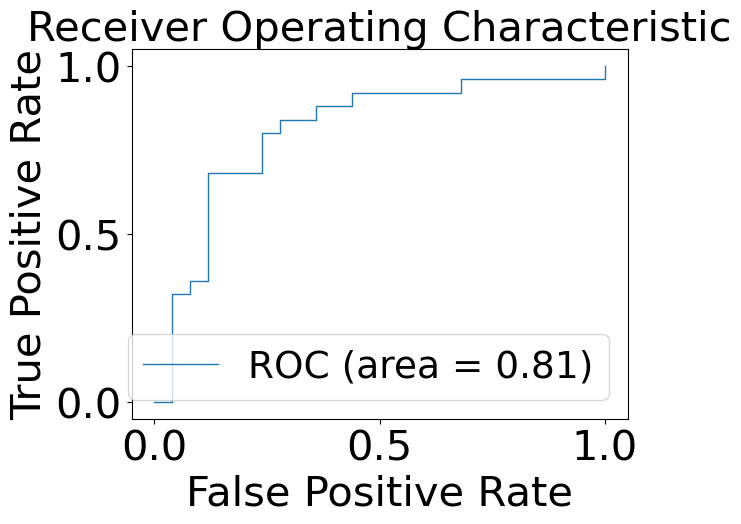

Crossvalidierte Ergebnisse on test data
              precision    recall  f1-score   support

           0       0.76      0.76      0.76        25
           1       0.76      0.76      0.76        25

    accuracy                           0.76        50
   macro avg       0.76      0.76      0.76        50
weighted avg       0.76      0.76      0.76        50



In [29]:
model = SVC(kernel='rbf', degree=3, gamma='scale', probability=True, class_weight='balanced')

space = {
    "pca__n_components": [5, 10, 15, 20, 25, 30],
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ['linear', 'rbf'],
    "model__gamma" : ['scale', 0.001, 0.01, 0.1, 1]
}

res_svm_nested_pca = myml.classification_10foldcv_nested_with_pca(X, y, model, space, 'yes')
res_svm_nested_pca.columns = ["y_true", "y_score"] 

## XGBoost

Here we are using a 10-fold Stratified Cross-Validation for model evaluation.
In each fold, the model is trained on the training set and evaluated on the
held-out test fold. Performance metrics (Accuracy, F1) are aggregated across
folds and overall predictions are used to compute ROC and confusion matrix.

>acc=0.800
>acc=0.600
>acc=1.000
>acc=0.600
>acc=1.000
>acc=1.000
>acc=0.800
>acc=0.800
>acc=0.600
>acc=0.800

y_true (echte Labels):
  Klasse 0 → 25 Samples
  Klasse 1 → 25 Samples

y_pred (Vorhersagen):
  Klasse 0 → 25 Samples
  Klasse 1 → 25 Samples
Accuracy: 0.800 (± 0.155)
F1-Score: 0.790 (± 0.162)


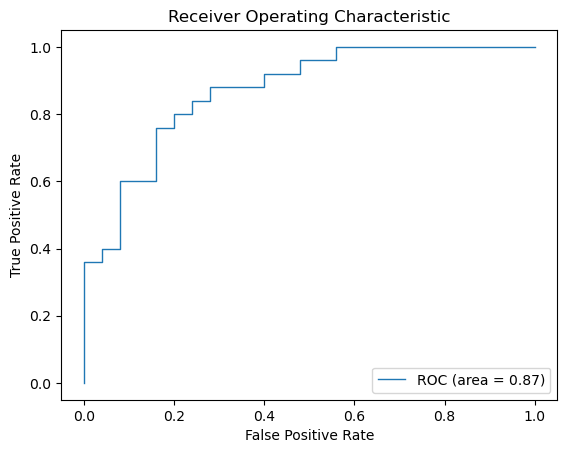

Crossvalidierte Ergebnisse on test data
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        25
           1       0.80      0.80      0.80        25

    accuracy                           0.80        50
   macro avg       0.80      0.80      0.80        50
weighted avg       0.80      0.80      0.80        50

Crossvalidierte Ergebnisse on training data
              precision    recall  f1-score   support

           0       0.74      0.80      0.77        25
           1       0.78      0.72      0.75        25

    accuracy                           0.76        50
   macro avg       0.76      0.76      0.76        50
weighted avg       0.76      0.76      0.76        50



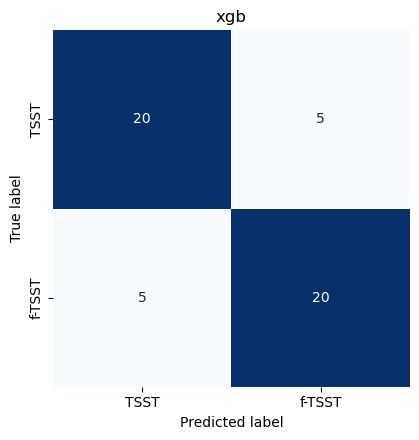

In [22]:
model = XGBClassifier(
    max_depth=1,
    gamma=2,
    eta=0.7,
    reg_alpha=0.7,
    reg_lambda=0.7,
    eval_metric='logloss'
)

res_xgb = myml.classification_10foldcv(X, y, model, 'xgb', 'yes')
res_xgb.columns = ["y_true", "y_score"] 

## XGBoost - nested

### with hyperparameter tuning (nested cv)

Here we are using a 10-fold Stratified Cross-Validation with nested 3-fold CV for hyperparameter tuning.
In each outer fold, the best model is selected using GridSearchCV on the training data
and then evaluated on the held-out test fold. Performance is compared to a majority
class baseline and repeated for all folds.

>acc=0.800
>acc=0.600
>acc=1.000
>acc=0.800
>acc=0.800
>acc=1.000
>acc=0.800
>acc=0.800
>acc=0.800
>acc=0.800

y_true (echte Labels):
  Klasse 0 → 25 Samples
  Klasse 1 → 25 Samples

y_pred (Vorhersagen):
  Klasse 0 → 26 Samples
  Klasse 1 → 24 Samples

y_pred_base (Baseline):
  Klasse 0 → 25 Samples
  Klasse 1 → 25 Samples
Accuracy: 0.820 (± 0.108)
F1-Score: 0.806 (± 0.117)


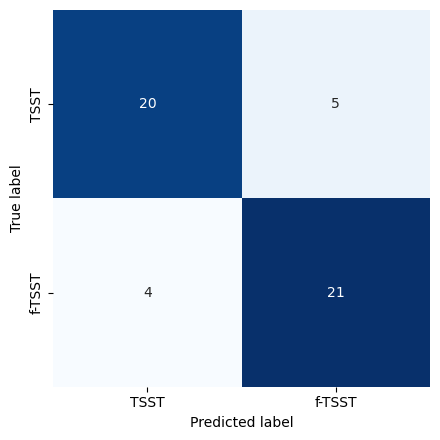

McNemar (Model vs Baseline)
statistic=13.793103448275861, p-value=0.00020408400998040742


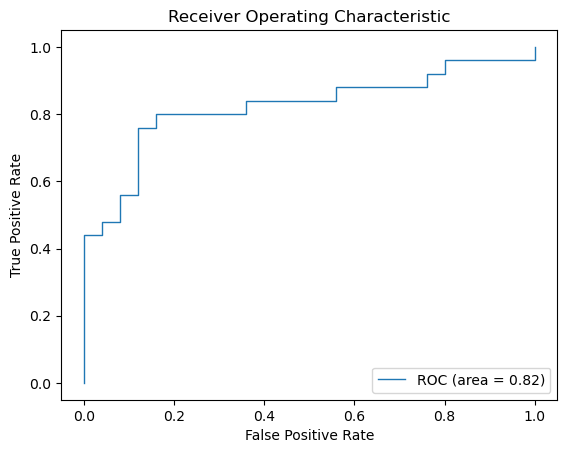

Crossvalidierte Ergebnisse on test data
              precision    recall  f1-score   support

           0       0.81      0.84      0.82        25
           1       0.83      0.80      0.82        25

    accuracy                           0.82        50
   macro avg       0.82      0.82      0.82        50
weighted avg       0.82      0.82      0.82        50

Crossvalidierte Ergebnisse on training data
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        25
           1       1.00      0.92      0.96        25

    accuracy                           0.96        50
   macro avg       0.96      0.96      0.96        50
weighted avg       0.96      0.96      0.96        50

Saved CSV (fold scores): xgb - nested_classification_kfold_fold_scores.csv


In [23]:
model = XGBClassifier(
    max_depth=1,
    gamma=2,
    eta=0.7,
    reg_alpha=0.7,
    reg_lambda=0.7,
    eval_metric='logloss'
)

space = {
    "max_depth": [1, 2, 4, 8],
    "learning_rate": [0.03, 0.1, 0.2],
    "n_estimators": [50, 100, 150],
}

res_xgb_nested = myml.classification_10foldcv_nested(X, y, model, 'xgb - nested', space, 'yes')
res_xgb_nested.columns = ["y_true", "y_score"] 

### with hyperparameter tuning (nested cv) and pca

Here we are using a 10-fold Stratified Cross-Validation with nested 3-fold CV for hyperparameter tuning.
A pipeline consisting of StandardScaler, PCA, and the classifier is used.
In each outer fold, the training data is used in a GridSearchCV with 3-fold CV
to select the best hyperparameters. PCA and scaling are fitted only on the
training data within each fold to avoid data leakage. The best pipeline is
then evaluated on the held-out test fold. This process is repeated for all folds.

>acc=1.000, est=0.756, cfg={'model__learning_rate': 0.03, 'model__max_depth': 1, 'model__n_estimators': 50, 'pca__n_components': 25}
>acc=0.600, est=0.689, cfg={'model__learning_rate': 0.1, 'model__max_depth': 1, 'model__n_estimators': 50, 'pca__n_components': 10}
>acc=0.800, est=0.733, cfg={'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 50, 'pca__n_components': 10}
>acc=0.600, est=0.756, cfg={'model__learning_rate': 0.03, 'model__max_depth': 1, 'model__n_estimators': 50, 'pca__n_components': 5}
>acc=1.000, est=0.733, cfg={'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 50, 'pca__n_components': 5}
>acc=1.000, est=0.644, cfg={'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 50, 'pca__n_components': 5}
>acc=0.600, est=0.644, cfg={'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 50, 'pca__n_components': 25}
>acc=0.600, est=0.733, cfg={'model__learning_rate': 0.03, 'model__max_dept

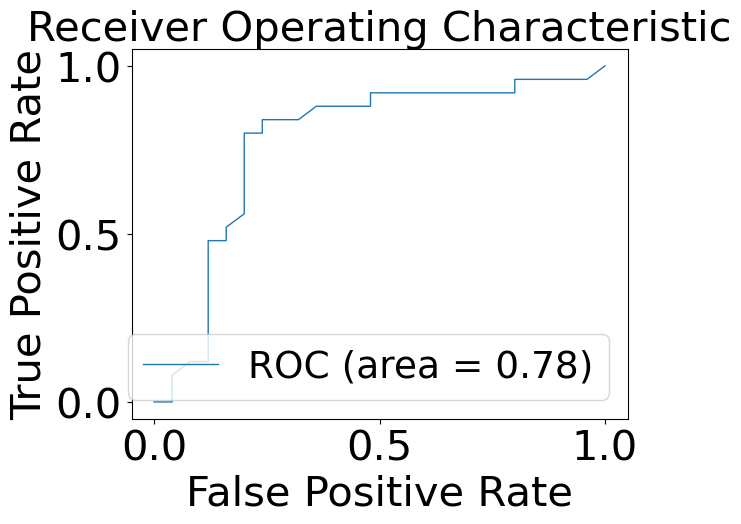

Crossvalidierte Ergebnisse on test data
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        25
           1       0.80      0.80      0.80        25

    accuracy                           0.80        50
   macro avg       0.80      0.80      0.80        50
weighted avg       0.80      0.80      0.80        50



In [31]:
model = XGBClassifier(
    max_depth=1,
    gamma=2,
    eta=0.7,
    reg_alpha=0.7,
    reg_lambda=0.7,
    eval_metric='logloss'
)

space = {
    "model__max_depth": [1, 2, 4, 8],
    "model__learning_rate": [0.03, 0.1, 0.2],
    "model__n_estimators": [50, 100, 150],
    "pca__n_components": [5, 10, 15, 20, 25, 30]
}

res_xgb_nested_pca = myml.classification_10foldcv_nested_with_pca(X, y, model, space, 'yes')
res_xgb_nested_pca.columns = ["y_true", "y_score"] 

### Shap Values XGBoost - nested

Here we compute the shap values for all features and safe the figure under "shap_all_features.pdf"

In [24]:
X_df = pd.DataFrame(X, columns=audio)

explainer = shap.Explainer(model, X_df)
shap_values = explainer(X_df)

shap.plots.bar(shap_values, show=False)

ax = plt.gca()

for patch in ax.patches:
    patch.set_color("blue")

for text in ax.texts:
    text.set_color("blue")

plt.savefig("shap_all_features.pdf", bbox_inches="tight")
plt.close()

Here we compute the shap values for the top 5 features and safe teh figure under "shap_top5_features.pdf"

In [25]:
X_df = pd.DataFrame(X, columns=audio) 

explainer = shap.Explainer(model, X_df)
shap_values = explainer(X_df)

mean_abs = np.abs(shap_values.values).mean(axis=0)      
top5_idx = np.argsort(mean_abs)[::-1][:5]               

shap_top5 = shap_values[:, top5_idx]

shap.plots.bar(shap_top5, max_display=5, show=False)


ax = plt.gca()
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.xaxis.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)
ax.set_xlabel("Mean absolute SHAP value", fontsize=17)
color = plt.get_cmap("Blues")(0.85)
for p in ax.patches:
    p.set_facecolor(color)

for t in ax.texts:
    t.set_color(color)
    

plt.tight_layout()
plt.savefig("shap_top5_features.pdf", bbox_inches="tight")
plt.close()

### Shap swarm plot

Here we compute a SHAP swarm plot, rename the feature names
to more interpretable labels for visualization and save the plot under "shap_swarm_top5_features.pdf"

In [28]:
feature_name_map = {
    "spectralFluxV_sma3nz_stddevNorm": "Variability of spectral flux",
    "spectrum_6": "Low-frequency spectral energy",
    "VoicedSegmentsPerSec": "Rate of voiced segments",
    "shimmerLocaldB_sma3nz_stddevNorm": "Variability of local shimmer",
    "spectrum_2": "Very-low-frequency spectral energy"
}

X_df = pd.DataFrame(X, columns=audio) 


explainer = shap.Explainer(model, X_df)
shap_values = explainer(X_df)

mean_abs = np.abs(shap_values.values).mean(axis=0)   
top5_idx = np.argsort(mean_abs)[::-1][:5]           

shap_top5 = shap_values[:, top5_idx]

top5_names = [X_df.columns[i] for i in top5_idx]

new_feature_names = [feature_name_map.get(name, name) for name in top5_names]

shap_top5.feature_names = new_feature_names

shap.plots.beeswarm(shap_top5, max_display=5, show=False)

fig = plt.gcf()
ax = plt.gca()
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.xaxis.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)
ax.set_xlabel("SHAP value", fontsize=17)

for label in ax.get_yticklabels():
    label.set_color("black")

cbar_ax = fig.axes[-1]                     
cbar_ax.tick_params(labelsize=14)          
cbar_ax.set_ylabel("Feature value", fontsize=16)

for t in cbar_ax.texts:
    t.set_fontsize(14)
    
plt.tight_layout()
plt.savefig("shap_swarm_top5_features.pdf", bbox_inches="tight")
plt.close()

### All ROC Graph

Here we ese the previously stored prediction scores from different models
to plot their ROC curves in a single combined figure.

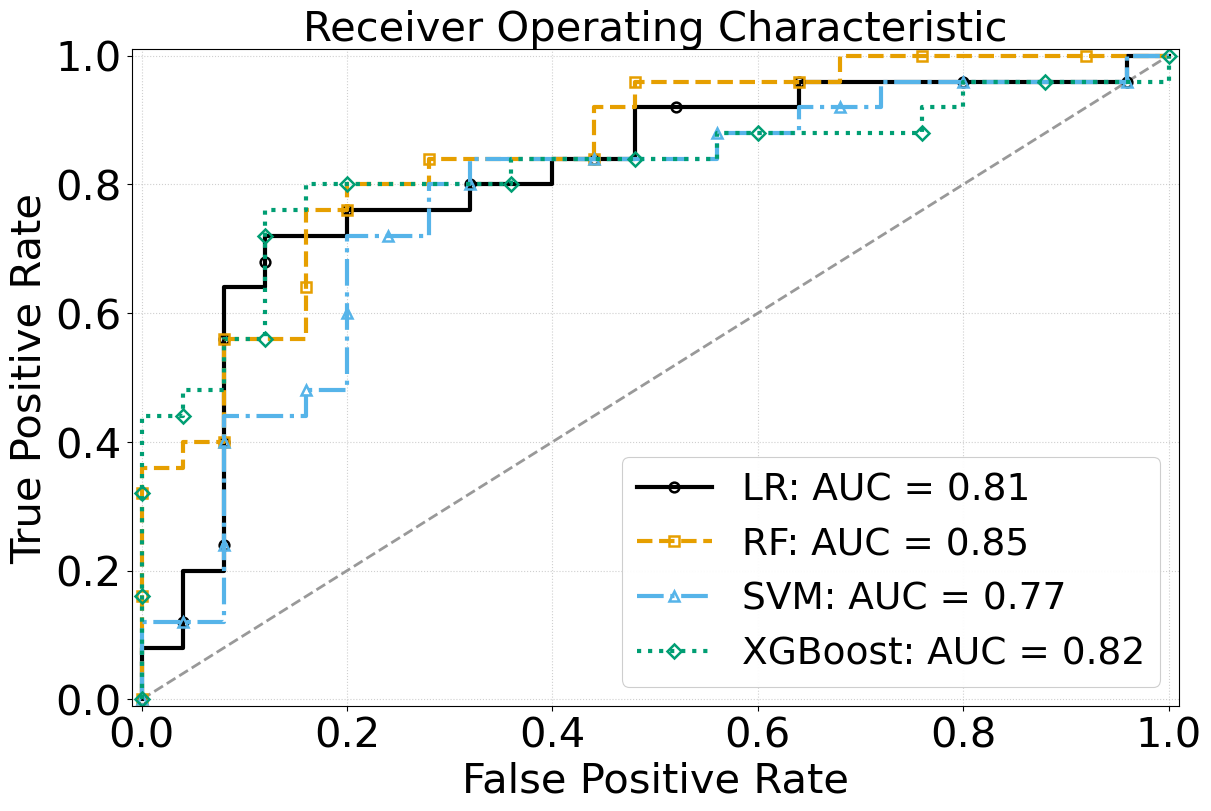

In [27]:
predictions = {
    "LR": res_lr_nested["y_score"].values,

    "RF": res_rf_nested["y_score"].values,

    "SVM": res_svm_nested["y_score"].values,

    "XGBoost": res_xgb_nested["y_score"].values,
}

y_true = res_lr["y_true"].values

myml.all_roc_graph_colorblindness(y_true, predictions, name="all_models")